# LangGraph Workflow Diagrams

Generates visual Mermaid diagrams for both compiled LangGraph graphs.

- **Load graph** — `extract_text → build_index → summarize`
- **QA graph** — `retrieve → answer`

Rendering uses `draw_mermaid_png()`, which calls the [mermaid.ink](https://mermaid.ink) API and returns PNG bytes displayed inline via `IPython.display.Image`.

In [1]:
import sys
from pathlib import Path

# Make the app package importable from this notebook
sys.path.insert(0, str(Path.cwd().parent))

from IPython.display import Image, Markdown, display
from app.graph import load_graph, qa_graph

In [2]:
def show_diagram(title: str, graph) -> None:
    """Display a graph's Mermaid source and its rendered PNG."""
    source = graph.get_graph().draw_mermaid()
    display(Markdown(f"## {title}"))
    display(Markdown(f"```mermaid\n{source}```"))
    display(Image(data=graph.get_graph().draw_mermaid_png()))

---
### Load Graph

## Load Graph (extract_text → build_index → summarize)

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	extract_text(extract_text)
	build_index(build_index)
	summarize(summarize)
	__end__([<p>__end__</p>]):::last
	__start__ --> extract_text;
	build_index --> summarize;
	extract_text --> build_index;
	summarize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc
```

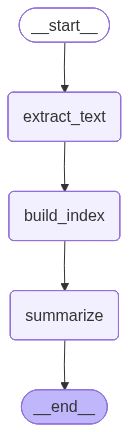

In [3]:
show_diagram("Load Graph (extract_text → build_index → summarize)", load_graph)

---
### QA Graph

## QA Graph (retrieve → answer)

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	retrieve(retrieve)
	answer(answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> retrieve;
	retrieve --> answer;
	answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc
```

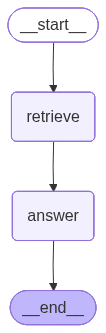

In [4]:
show_diagram("QA Graph (retrieve → answer)", qa_graph)